In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
sys.path.append("..")

In [2]:
df = pd.read_csv(r"D:\ML_work\Predictive-Maintenance\data\ai4i2020.csv")

In [3]:
features = ["Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]"
            ]

In [4]:
X = df[features]
y = df["Machine failure"]

print(f"X shape: {X.shape}\ny shape: {y.shape}")

X shape: (10000, 5)
y shape: (10000,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)
print(f"X_train: {X_train.shape}\nX_test: {X_test.shape}")

X_train: (8000, 5)
X_test: (2000, 5)


In [6]:
import utils.preprocessing
importlib.reload(utils.preprocessing)
from utils.preprocessing import z_score
scalre = z_score()
X_stan = scalre.fit(X_train)

In [7]:
import utils.models
importlib.reload(utils.models)
from utils.models import logistic_regression

In [8]:
log_reg = logistic_regression(learning_rate=0.1, iterations=1000)

In [9]:
log_reg.fit(X_stan, y_train)

Epoch 0 cost: 0.6931471805599454
Epoch 100 cost: 0.18724544047388827
Epoch 200 cost: 0.1473924521551179
Epoch 300 cost: 0.13437831241010234
Epoch 400 cost: 0.12755918288957344
Epoch 500 cost: 0.1230708891629684
Epoch 600 cost: 0.11972760309810324
Epoch 700 cost: 0.11705076431470653
Epoch 800 cost: 0.11481097583231512
Epoch 900 cost: 0.11288497369685058
Epoch 999 cost: 0.11121663802311817


In [10]:
print(log_reg.w)
print(log_reg.b)

Air temperature [K]        0.478553
Process temperature [K]   -0.151255
Rotational speed [rpm]     0.719610
Torque [Nm]                1.233596
Tool wear [min]            0.471948
dtype: float64
-3.6111996853877213


In [11]:
log_reg.fit(X_stan, y_train)

Epoch 0 cost: 0.11120083099252799
Epoch 100 cost: 0.10971356968800729
Epoch 200 cost: 0.10839304229983006
Epoch 300 cost: 0.10721744654224599
Epoch 400 cost: 0.10616973259747255
Epoch 500 cost: 0.10523563124526493
Epoch 600 cost: 0.10440262744620318
Epoch 700 cost: 0.10365947350385958
Epoch 800 cost: 0.10299598479115951
Epoch 900 cost: 0.10240296105834405
Epoch 999 cost: 0.1018771721330267


In [12]:
X_test_stan = scalre.transform(X_test)

In [13]:
prob = log_reg.predict_prob(X_test_stan)

In [14]:
print(prob[:10])
print(prob.shape)

[0.36183091 0.04259806 0.05956651 0.00223176 0.19632566 0.06692045
 0.05980238 0.01713608 0.00899762 0.03556295]
(2000,)


In [15]:
y_pred = log_reg.predict(X_test_stan)

In [16]:
print(y_pred[:10])
print(y_pred.shape)

[0 0 0 0 0 0 0 0 0 0]
(2000,)


In [35]:
importlib.reload(utils.evaluation)
from utils.evaluation import confusion_matrix, precision, recall, f1_score, false_positive_rate

In [18]:
cm = confusion_matrix(y_test, y_pred)
p = precision(y_test, y_pred)
r = recall(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(cm)
print("Precision:", p)
print("Recall:", r)
print("F1:", f1)

[[1932    0]
 [  62    6]]
Precision: 1.0
Recall: 0.08823529411764706
F1: 0.1621621621621622


In [19]:
print(prob.max())
print(prob.min())
print(f"Mean: {prob.mean()}")

0.6311261313208392
0.0007085244417939109
Mean: 0.03571756236688538


In [20]:
print(prob[y_test == 1][:20])

[0.08393003 0.22113939 0.16203649 0.58607709 0.11014897 0.2065732
 0.19128362 0.01950227 0.01382457 0.02872995 0.26614881 0.11934545
 0.17275485 0.11044224 0.60713035 0.10826485 0.13230908 0.12374813
 0.0421537  0.43939224]


In [21]:
print(prob[y_test == 0][:20])

[0.36183091 0.04259806 0.05956651 0.00223176 0.19632566 0.06692045
 0.05980238 0.01713608 0.00899762 0.03556295 0.02267913 0.03767897
 0.00537222 0.02120472 0.0191901  0.07304056 0.01874592 0.00318253
 0.01886161 0.01878267]


In [43]:
thresholds = np.arange(0.00, 1, 0.01)

In [44]:
f1_scores = []
for threshold in thresholds:
    y_pred_test = (prob > threshold).astype(int)
    f1 = f1_score(y_test, y_pred_test)
    f1_scores.append(f1)

In [45]:
best_index = np.argmax(f1_scores)
best_f1 = f1_scores[best_index]
print(f"Best f1: {best_f1}, Best index: {best_index}")

Best f1: 0.4657534246575343, Best index: 15


In [46]:
threshold = thresholds[best_index]

y_pred_best = (prob > threshold).astype(int)

print("Threshold:", threshold)
print("Precision:", precision(y_test, y_pred_best))
print("Recall:", recall(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Threshold: 0.15
Precision: 0.4358974358974359
Recall: 0.5
F1: 0.4657534246575343
Confusion Matrix:
 [[1888   44]
 [  34   34]]


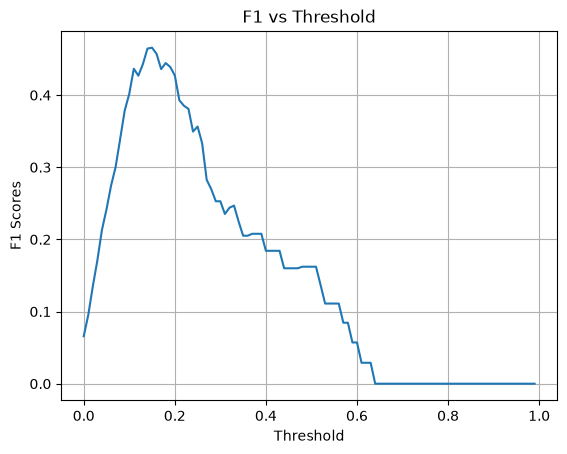

In [47]:
plt.plot(thresholds, f1_scores)
plt.title("F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Scores")
plt.grid()
plt.show()

In [48]:
precision_scores = []
recall_scores = []
fpr_scores = []

for threshold in thresholds:
    y_pred_test = (prob > threshold).astype(int)

    precision_scores.append(precision(y_test, y_pred_test))

    recall_scores.append(recall(y_test, y_pred_test))

    fpr_scores.append(false_positive_rate(y_test, y_pred_test))

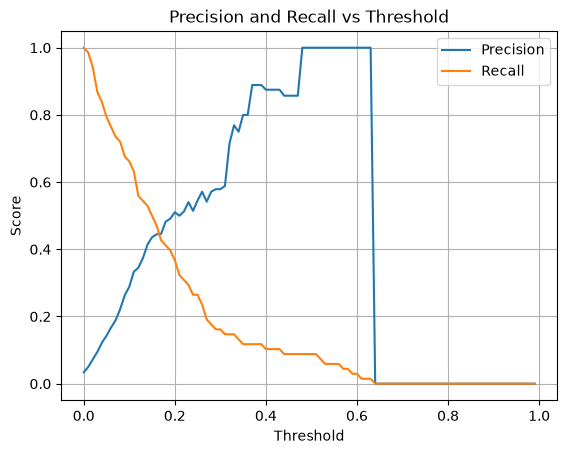

In [49]:
plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, recall_scores, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

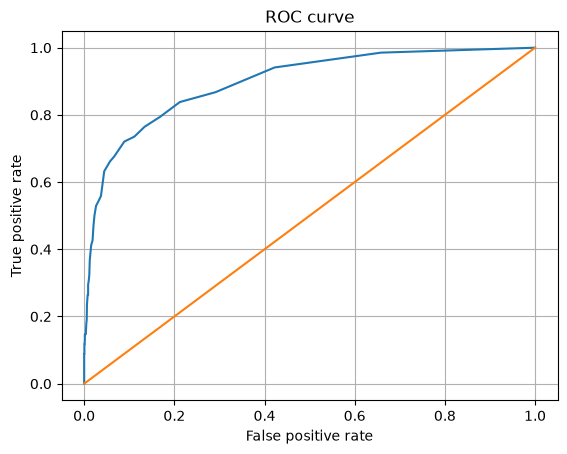

In [50]:
plt.plot(fpr_scores, recall_scores)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.grid()
plt.show()

In [56]:
fpr_sorted = fpr_scores[::-1]
tpr_sorted = recall_scores[::-1]
auc = 0
for i in range(len(fpr_sorted)-1):
    width = fpr_sorted[i+1] - fpr_sorted[i]
    height = (tpr_sorted[i] + tpr_sorted[i+1]) / 2
    auc = auc + width * height
print(f"AUC: {auc}")

AUC: 0.8976982097186701
